# cleaning and loading 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import ast
import os
from tqdm import tqdm
import seaborn as sns

def load_and_clean_data(filepath):
    """Load and clean the point machine data"""
    # Load the raw data
    df = pd.read_csv(filepath)
    
    # Clean time format - handle cases where time uses '.' instead of ':'
    df['Time'] = df['Time'].str.replace('.', ':', regex=False)
    
    # Convert to datetime - handle multiple possible formats
    try:
        df['Time'] = pd.to_datetime(df['Time'], format='%d-%m-%Y %H:%M')
    except:
        try:
            df['Time'] = pd.to_datetime(df['Time'], format='%m-%d-%Y %H:%M')
        except:
            df['Time'] = pd.to_datetime(df['Time'])
    
    # Clean the list-like columns by converting string representations to lists
    list_columns = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
    
    for col in list_columns:
        # Handle cases where lists might be malformed
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        
        # Ensure all elements are floats
        df[col] = df[col].apply(lambda lst: [float(x) if str(x).replace('.','',1).isdigit() else 0.0 for x in lst])
    
    # Standardize text columns
    text_columns = ['Site Name', 'Point Machine Name', 'Direction', 'Type of A', 'Type of B']
    for col in text_columns:
        df[col] = df[col].str.strip().str.title()
    
    # Ensure polling columns are numeric
    df['Polling of A'] = pd.to_numeric(df['Polling of A'], errors='coerce').fillna(100)
    df['Polling of B'] = pd.to_numeric(df['Polling of B'], errors='coerce').fillna(100)
    
    return df

# Load your dataset
file_path = "/Users/anamikasaroha/Energy7_Week1/week_6/SECR2_TWS.csv"  
df = load_and_clean_data(file_path)

In [2]:
df.head()

,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B
0,2025-02-10 09:37:00,Mandir Hasaud,Pt71,Reverse,"[0.0, 2.3, 2.8, 2.0, 1.5, 1.3, 1.2, 1.2, 1.2, ...","[0.0, 55.5, 93.0, 111.0, 120.0, 124.5, 127.5, ...","[0.0, 3.3, 2.5, 1.9, 1.5, 1.2, 1.1, 1.0, 1.0, ...","[0.0, 18.0, 75.0, 102.0, 115.5, 123.0, 126.0, ...",Tws,Tws,100,100
1,2025-02-10 10:23:00,Mandir Hasaud,Pt71,Reverse,"[0.0, 3.3, 2.5, 1.8, 1.4, 1.2, 1.2, 1.2, 1.2, ...","[0.0, 45.0, 88.5, 109.5, 118.5, 124.5, 127.5, ...","[0.0, 3.3, 2.5, 1.8, 1.4, 1.2, 1.1, 1.0, 1.0, ...","[0.0, 57.0, 94.5, 112.5, 121.5, 126.0, 127.5, ...",Tws,Tws,100,100
2,2025-02-10 10:29:00,Mandir Hasaud,Pt71,Normal,"[0.0, 3.3, 2.4, 1.8, 1.4, 1.2, 1.3, 1.3, 1.3, ...","[0.0, 60.0, 94.5, 112.5, 121.5, 126.0, 127.5, ...","[0.0, 3.0, 2.2, 1.6, 1.3, 1.1, 1.0, 1.0, 1.0, ...","[0.0, 10.5, 70.5, 100.5, 114.0, 121.5, 126.0, ...",Tws,Tws,100,100
3,2025-02-10 09:58:00,Mandir Hasaud,Pt71,Normal,"[0.0, 1.4, 2.9, 2.1, 1.6, 1.3, 1.2, 1.3, 1.2, ...","[0.0, 10.5, 72.0, 100.5, 115.5, 123.0, 126.0, ...","[0.0, 3.1, 2.3, 1.7, 1.4, 1.1, 1.0, 1.0, 1.0, ...","[0.0, 52.5, 91.5, 111.0, 120.0, 124.5, 127.5, ...",Tws,Tws,100,100
4,2025-02-10 16:32:00,Mandir Hasaud,Pt71,Reverse,"[0.0, 2.9, 2.6, 1.9, 1.5, 1.3, 1.2, 1.2, 1.3, ...","[0.0, 60.0, 96.0, 112.5, 120.0, 124.5, 126.0, ...","[0.0, 3.2, 2.4, 1.8, 1.4, 1.2, 1.1, 1.0, 1.0, ...","[0.0, 22.5, 76.5, 105.0, 117.0, 124.5, 126.0, ...",Tws,Tws,100,100


# Datset Analysis 

=== Dataset Overview ===
Total records: 17790
Time range: 2024-08-10 00:05:00 to 2025-02-10 17:20:00

=== Point Machines ===
Point Machine Name
Pt154    5332
Pt77     5088
Pt76     2525
Pt57     1912
Pt71      996
Pt54      856
Pt74      422
Pt103     346
Pt41      313
Name: count, dtype: int64

=== Directions ===
Direction
Reverse    8979
Normal     8811
Name: count, dtype: int64

=== Signal Statistics ===
       A Current Length  B Current Length  A Voltage Length  B Voltage Length
count      17790.000000      17790.000000      17790.000000      17790.000000
mean          33.918999         34.960483         53.878246         58.937043
std           22.144110         25.628265         42.625289         44.126943
min            3.000000          3.000000          3.000000          3.000000
25%           29.000000         29.000000         33.000000         34.000000
50%           31.000000         31.000000         36.000000         35.000000
75%           33.000000         33.000000  

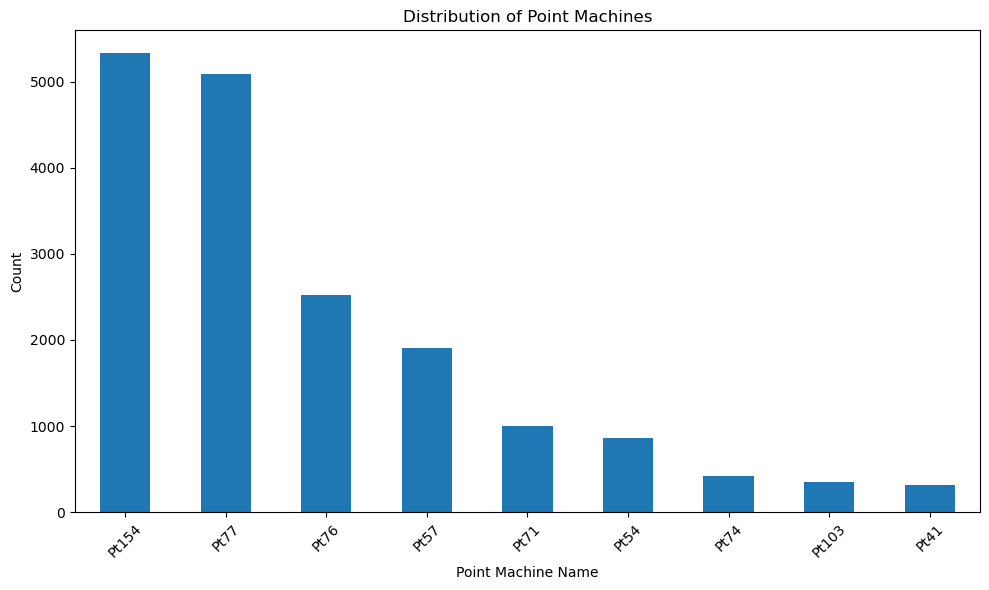

In [3]:
def analyze_dataset(df):
    """Analyze the dataset and print key statistics"""
    print("=== Dataset Overview ===")
    print(f"Total records: {len(df)}")
    print(f"Time range: {df['Time'].min()} to {df['Time'].max()}")
    
    print("\n=== Point Machines ===")
    machine_counts = df['Point Machine Name'].value_counts()
    print(machine_counts)
    
    print("\n=== Directions ===")
    print(df['Direction'].value_counts())
    
    print("\n=== Signal Statistics ===")
    signal_stats = pd.DataFrame({
        'A Current Length': df['A Current'].apply(len),
        'B Current Length': df['B Current'].apply(len),
        'A Voltage Length': df['A Voltage'].apply(len),
        'B Voltage Length': df['B Voltage'].apply(len)
    }).describe()
    print(signal_stats)
    
    # Plot distribution of point machines
    plt.figure(figsize=(10, 6))
    machine_counts.plot(kind='bar')
    plt.title('Distribution of Point Machines')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return machine_counts

machine_counts = analyze_dataset(df)

# Signal Analysis 

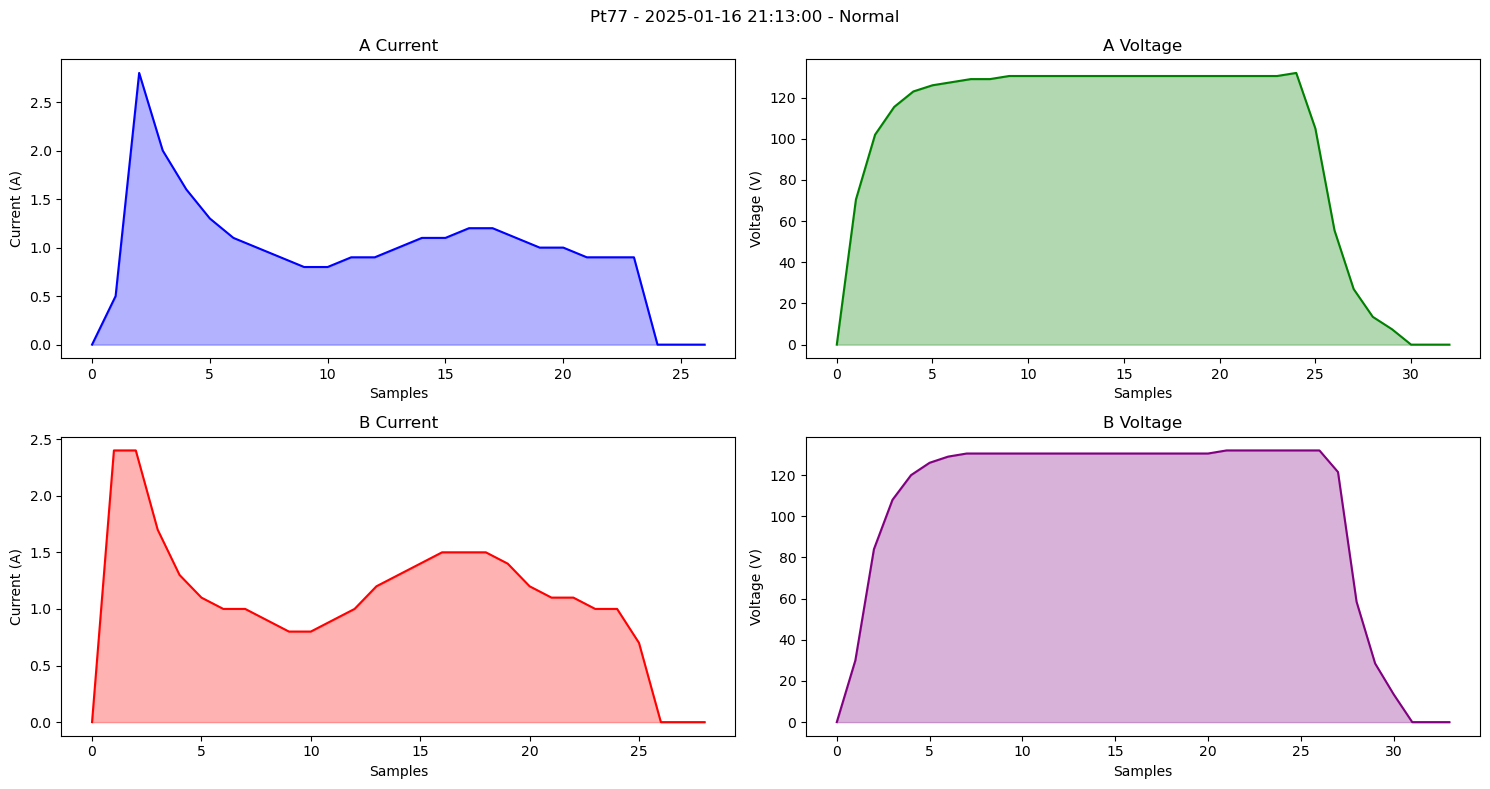

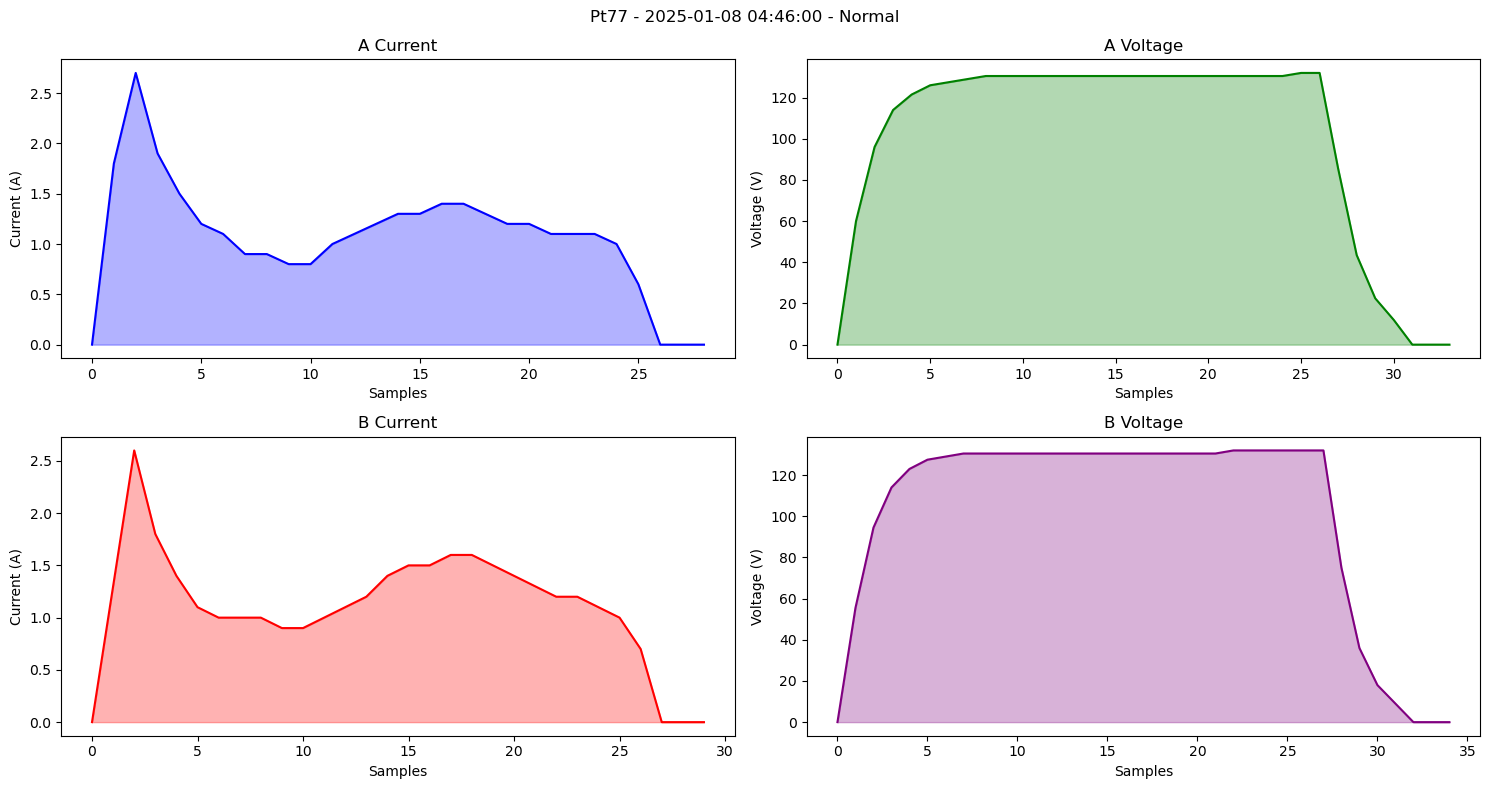

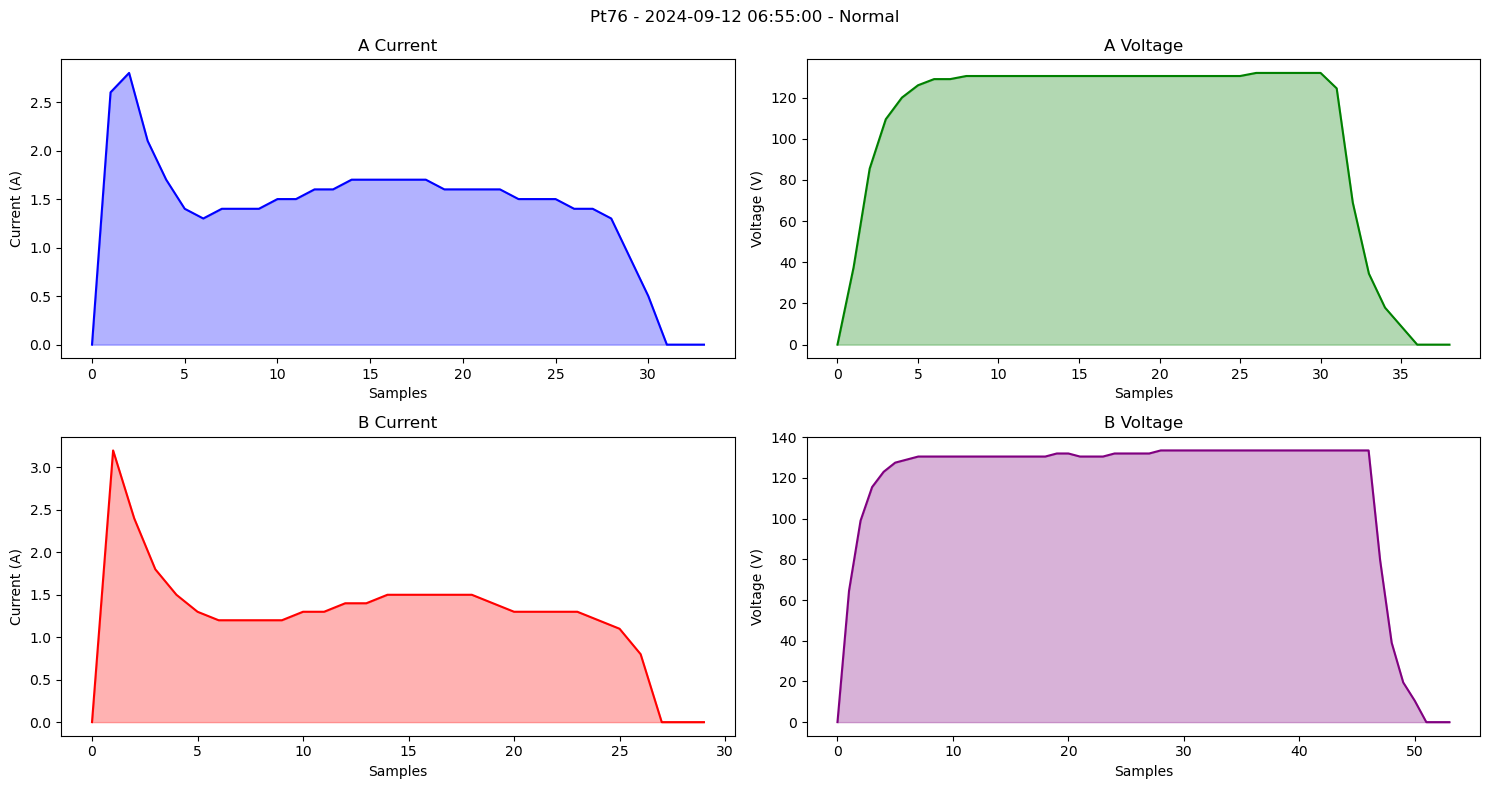

In [4]:
def plot_sample_signals(df, n_samples=3):
    """Plot sample signals from the dataset"""
    sample_df = df.sample(n_samples)
    
    for _, row in sample_df.iterrows():
        plt.figure(figsize=(15, 8))
        plt.suptitle(f"{row['Point Machine Name']} - {row['Time']} - {row['Direction']}")
        
        # A Current
        plt.subplot(2, 2, 1)
        plt.plot(row['A Current'], color='blue')
        plt.fill_between(range(len(row['A Current'])), row['A Current'], color='blue', alpha=0.3)
        plt.title('A Current')
        plt.xlabel('Samples')
        plt.ylabel('Current (A)')
        
        # A Voltage
        plt.subplot(2, 2, 2)
        plt.plot(row['A Voltage'], color='green')
        plt.fill_between(range(len(row['A Voltage'])), row['A Voltage'], color='green', alpha=0.3)
        plt.title('A Voltage')
        plt.xlabel('Samples')
        plt.ylabel('Voltage (V)')
        
        # B Current
        plt.subplot(2, 2, 3)
        plt.plot(row['B Current'], color='red')
        plt.fill_between(range(len(row['B Current'])), row['B Current'], color='red', alpha=0.3)
        plt.title('B Current')
        plt.xlabel('Samples')
        plt.ylabel('Current (A)')
        
        # B Voltage
        plt.subplot(2, 2, 4)
        plt.plot(row['B Voltage'], color='purple')
        plt.fill_between(range(len(row['B Voltage'])), row['B Voltage'], color='purple', alpha=0.3)
        plt.title('B Voltage')
        plt.xlabel('Samples')
        plt.ylabel('Voltage (V)')
        
        plt.tight_layout()
        plt.show()

plot_sample_signals(df)

# Creating the dataset 

In [5]:
def create_minimalist_images(df, output_dir="a_current_dataset", target_per_machine=50):
    """
    Create minimalist filled-area images of A Current signals,
    organized by point machine folders
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Create machine folders and track counts
    machine_counts = {}
    for machine in df['Point Machine Name'].unique():
        machine_path = os.path.join(output_dir, machine)
        os.makedirs(machine_path, exist_ok=True)
        machine_counts[machine] = 0
    
    # First pass - create images from real data
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing signals"):
        machine = row['Point Machine Name']
        signal = row['A Current']
        
        # Create minimalist plot
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.fill_between(range(len(signal)), signal, color='royalblue', alpha=0.7)
        
        # Remove all borders and labels
        ax.set_axis_off()
        fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
        
        # Save as PNG with minimal whitespace
        filename = f"{row['Time'].strftime('%Y%m%d_%H%M%S')}_{row['Direction']}.png"
        plt.savefig(
            os.path.join(output_dir, machine, filename),
            bbox_inches='tight',
            pad_inches=0,
            dpi=100,
            transparent=True
        )
        plt.close()
        
        machine_counts[machine] += 1
    
    # Second pass - augment if needed to reach target count
    for machine, count in tqdm(machine_counts.items(), desc="Augmenting data"):
        while count < target_per_machine:
            sample = df[df['Point Machine Name'] == machine].sample(1).iloc[0]
            augmented = augment_signal(sample['A Current'])
            
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.fill_between(range(len(augmented)), augmented, color='royalblue', alpha=0.7)
            ax.set_axis_off()
            fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
            
            filename = f"aug_{count}_{sample['Time'].strftime('%Y%m%d_%H%M%S')}_{sample['Direction']}.png"
            plt.savefig(
                os.path.join(output_dir, machine, filename),
                bbox_inches='tight',
                pad_inches=0,
                dpi=100,
                transparent=True
            )
            plt.close()
            
            count += 1
            machine_counts[machine] = count

    return machine_counts

def augment_signal(signal, noise_scale=0.03, stretch_range=(0.85, 1.15)):
    """Create augmented version of a signal with slight variations"""
    # Add noise
    noisy = signal + np.random.normal(0, noise_scale, len(signal))
    
    # Time stretching
    stretch_factor = np.random.uniform(*stretch_range)
    old_indices = np.linspace(0, len(noisy)-1, len(noisy))
    new_indices = np.linspace(0, len(noisy)-1, int(len(noisy)*stretch_factor))
    
    if len(new_indices) < 2:
        return signal
        
    return np.interp(new_indices, old_indices, noisy)



Creating image dataset...


Processing signals:   1%|          | 218/17790 [00:05<06:46, 43.25it/s]


KeyboardInterrupt: 

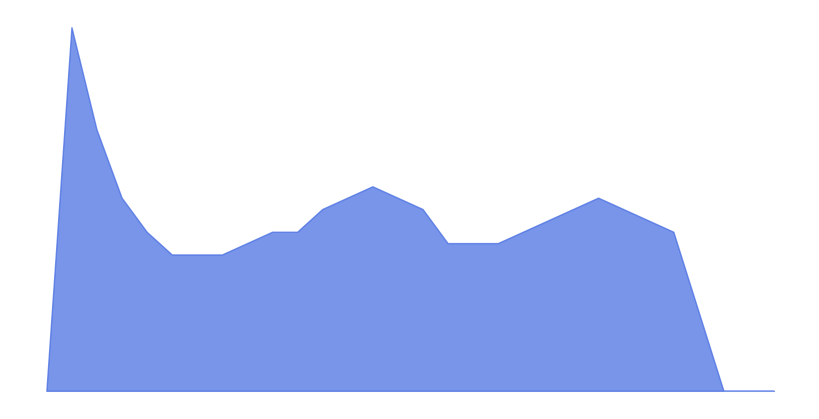

In [6]:
 #  Create minimalist dataset
print("\nCreating image dataset...")
counts = create_minimalist_images(df)

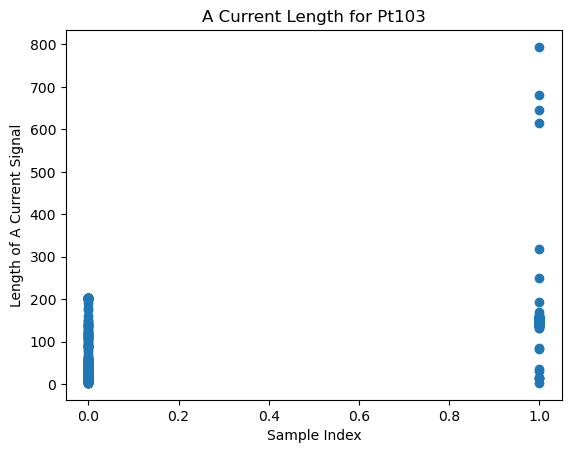

In [7]:
plt.plot(df['Point Machine Name'] == 'Pt103', df['A Current'].apply(len), 'o')
plt.title('A Current Length for Pt103')
plt.xlabel('Sample Index')
plt.ylabel('Length of A Current Signal')
plt.show()

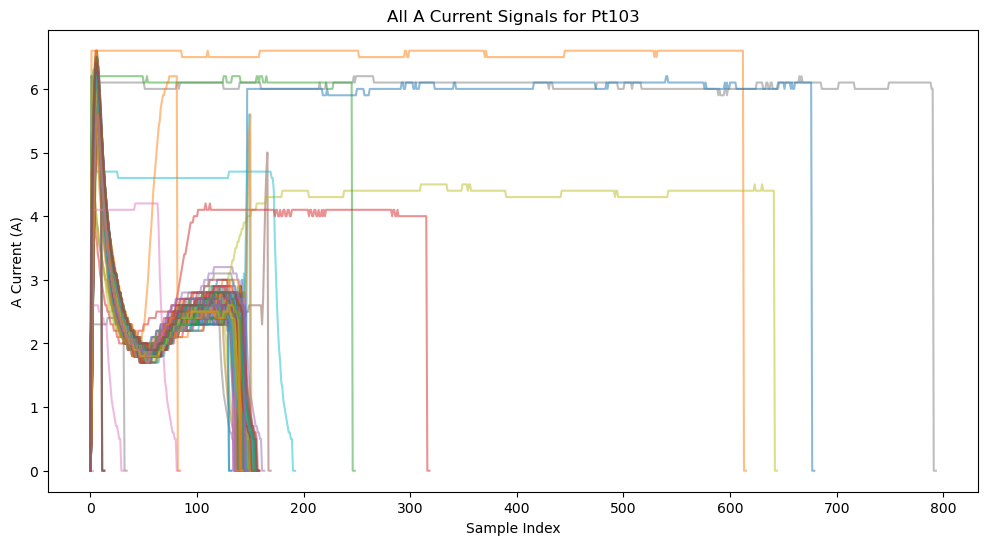

In [8]:
# Filter the dataframe for Pt103
pt103_df = df[df['Point Machine Name'] == 'Pt103']

# Plot all A Current signals for Pt103
plt.figure(figsize=(12, 6))
for idx, row in pt103_df.iterrows():
    plt.plot(row['A Current'], alpha=0.5)

plt.title('All A Current Signals for Pt103')
plt.xlabel('Sample Index')
plt.ylabel('A Current (A)')
plt.show()

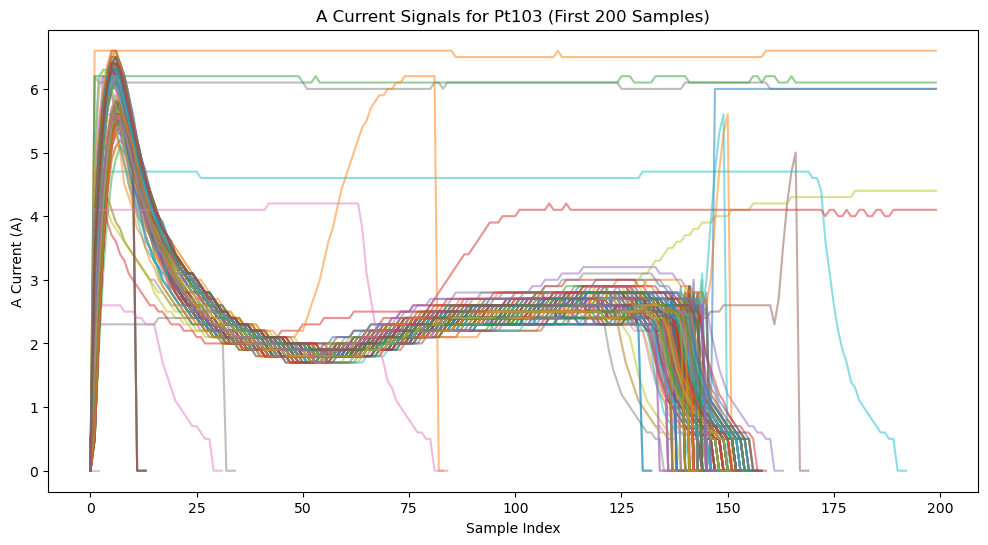

In [9]:
# Plot all A Current signals for Pt103, limited to sample indices 0-200
plt.figure(figsize=(12, 6))
for idx, row in pt103_df.iterrows():
    signal = row['A Current'][:200]  # Take only first 200 samples
    plt.plot(signal, alpha=0.5)

plt.title('A Current Signals for Pt103 (First 200 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('A Current (A)')
plt.show()

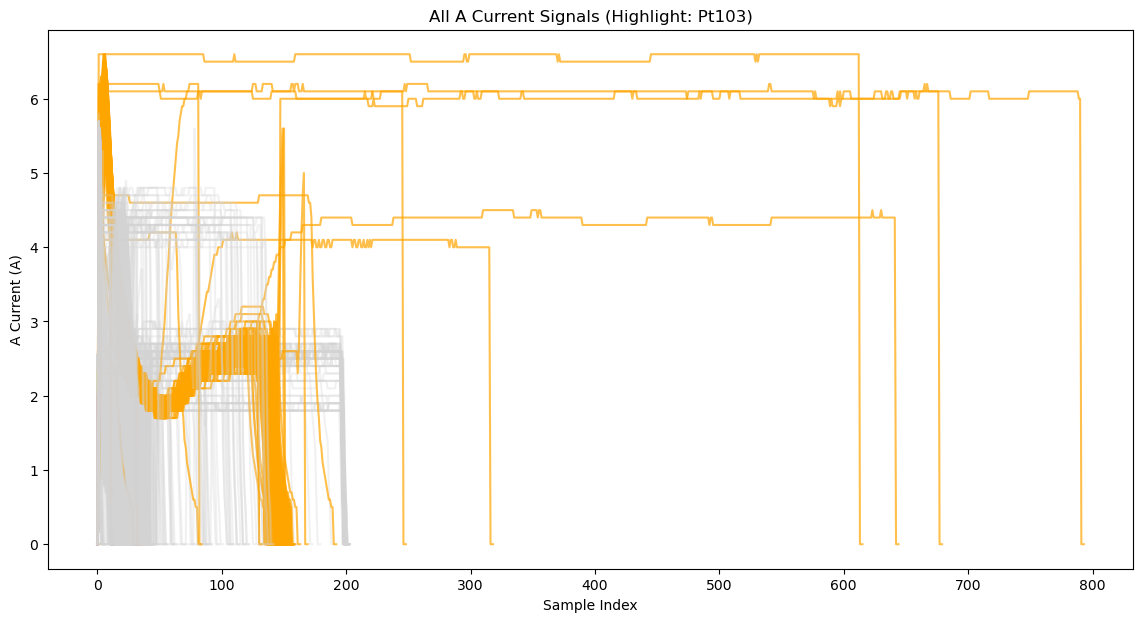

In [10]:
# Plot all A Current signals for all point machines, highlighting a specific one (e.g., Pt103) in a different color
highlight_machine = 'Pt103'

plt.figure(figsize=(14, 7))
for idx, row in df.iterrows():
    color = 'orange' if row['Point Machine Name'] == highlight_machine else 'lightgray'
    alpha = 0.7 if row['Point Machine Name'] == highlight_machine else 0.3
    plt.plot(row['A Current'], color=color, alpha=alpha)

plt.title(f'All A Current Signals (Highlight: {highlight_machine})')
plt.xlabel('Sample Index')
plt.ylabel('A Current (A)')
plt.show()

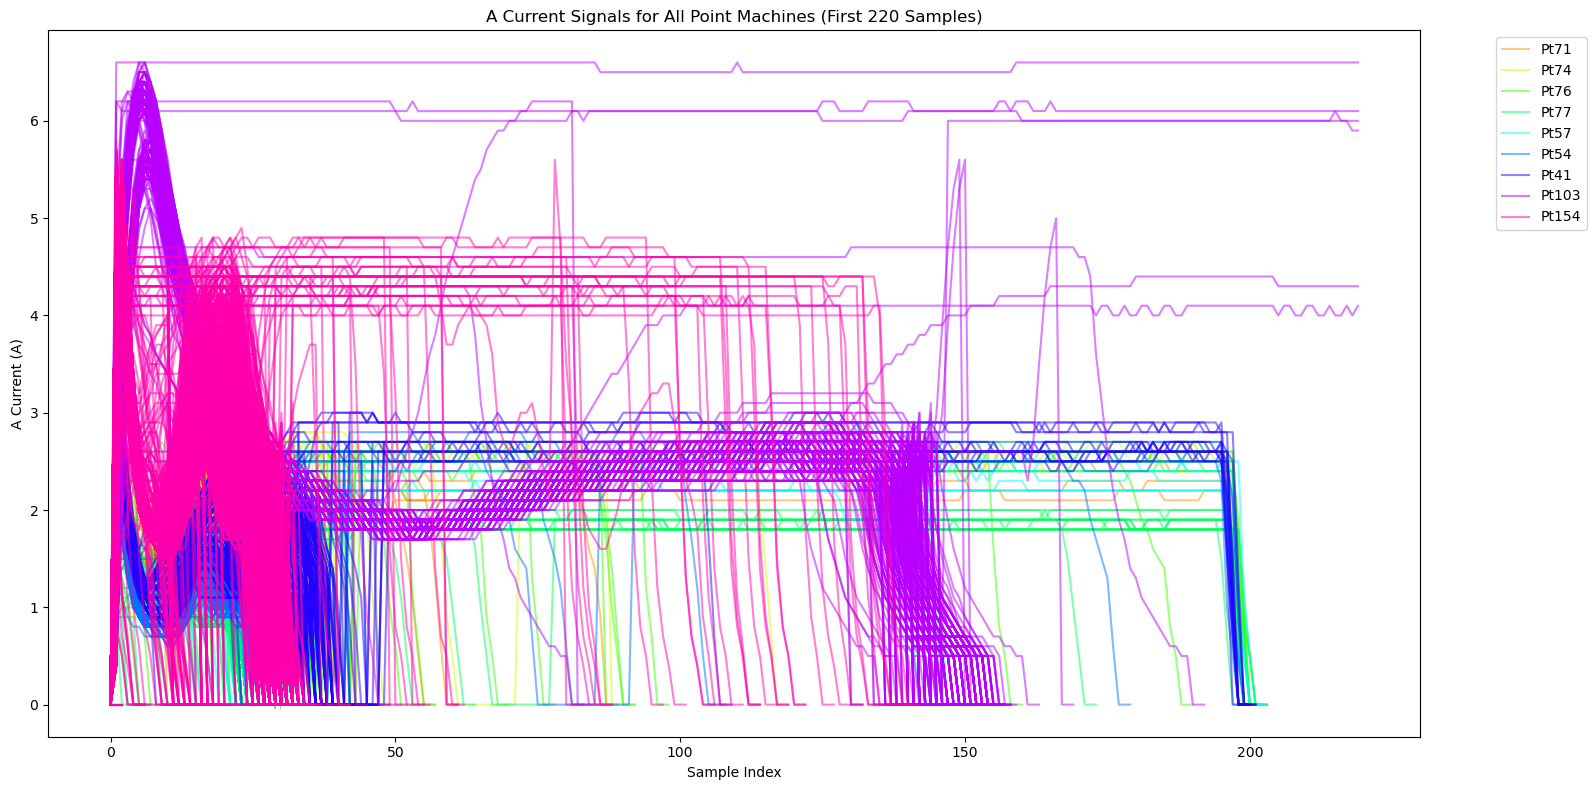

In [11]:
# Assign a unique color to each point machine
unique_machines = df['Point Machine Name'].unique()
palette = sns.color_palette('hsv', len(unique_machines))
machine_color_map = {machine: palette[i] for i, machine in enumerate(unique_machines)}

plt.figure(figsize=(16, 8))
for idx, row in df.iterrows():
    machine = row['Point Machine Name']
    signal = row['A Current'][:220]
    plt.plot(signal, color=machine_color_map[machine], alpha=0.5, label=machine if idx == df[df['Point Machine Name'] == machine].index[0] else "")

plt.title('A Current Signals for All Point Machines (First 220 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('A Current (A)')
# Only show one legend entry per machine
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

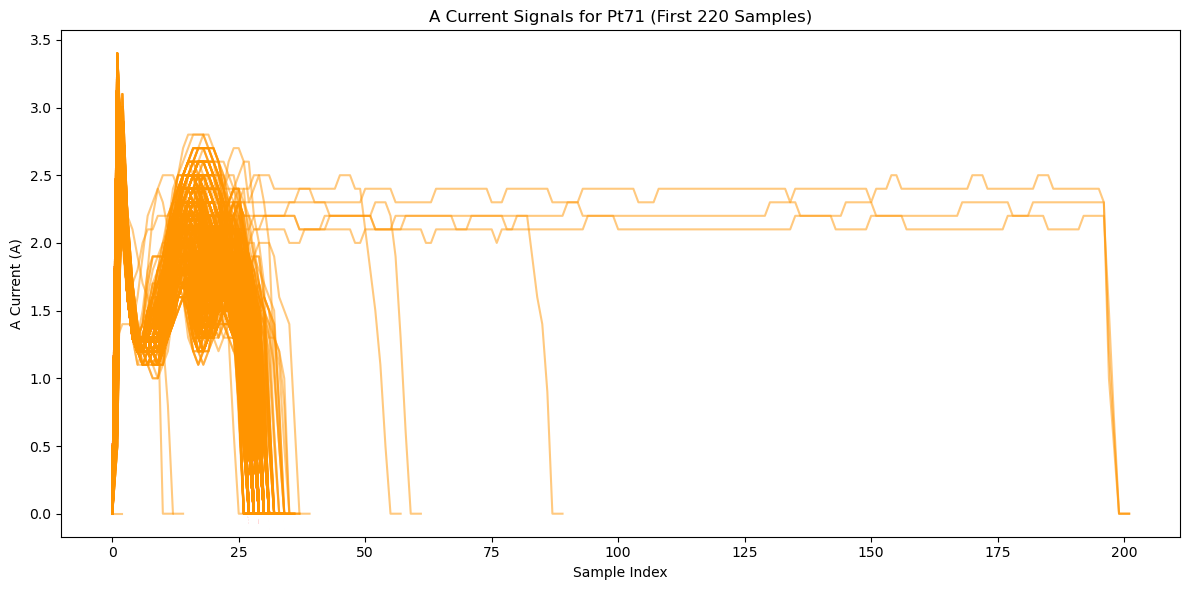

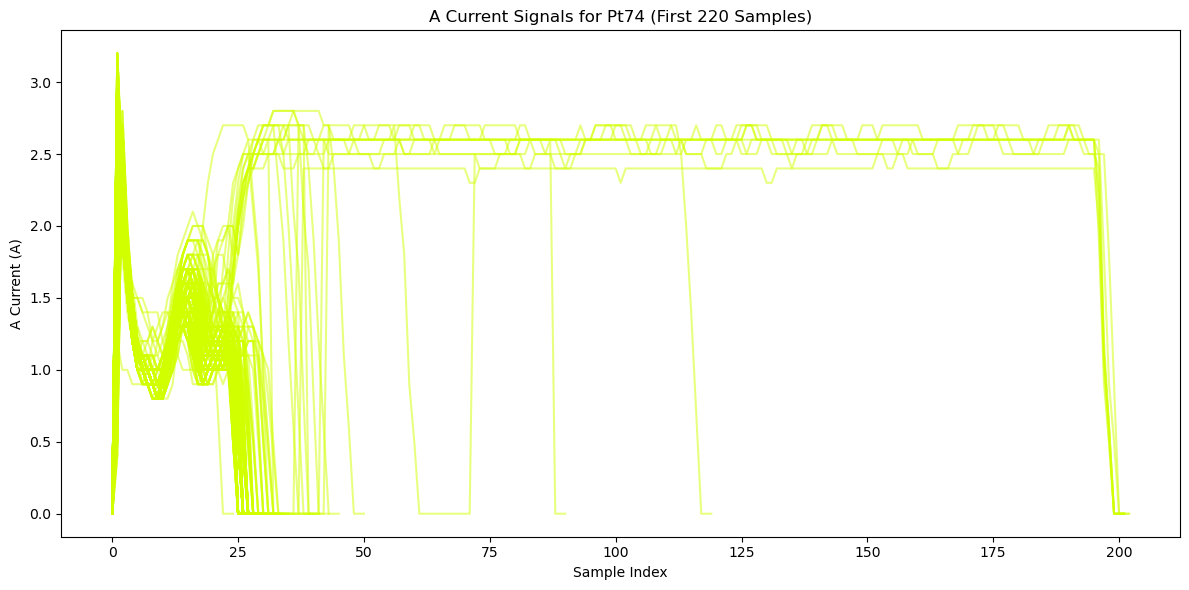

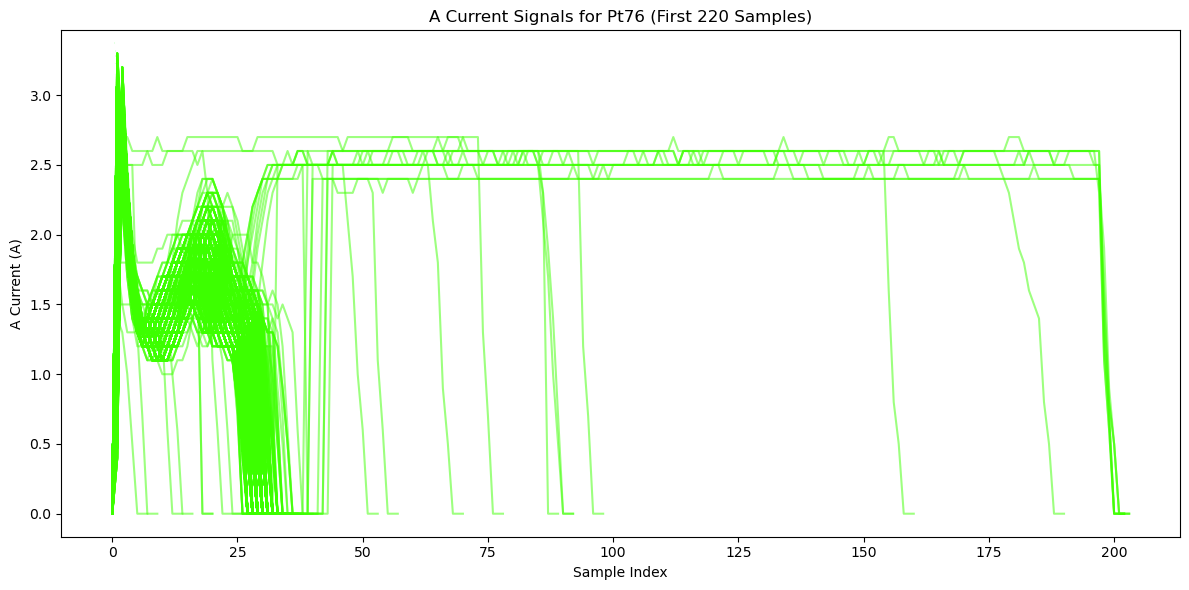

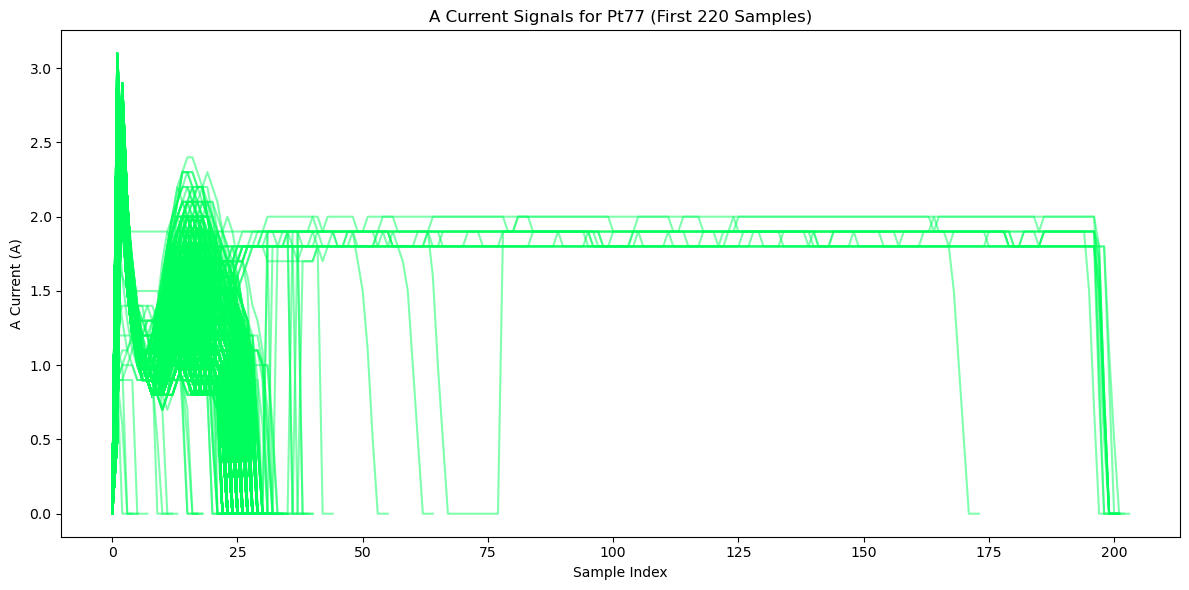

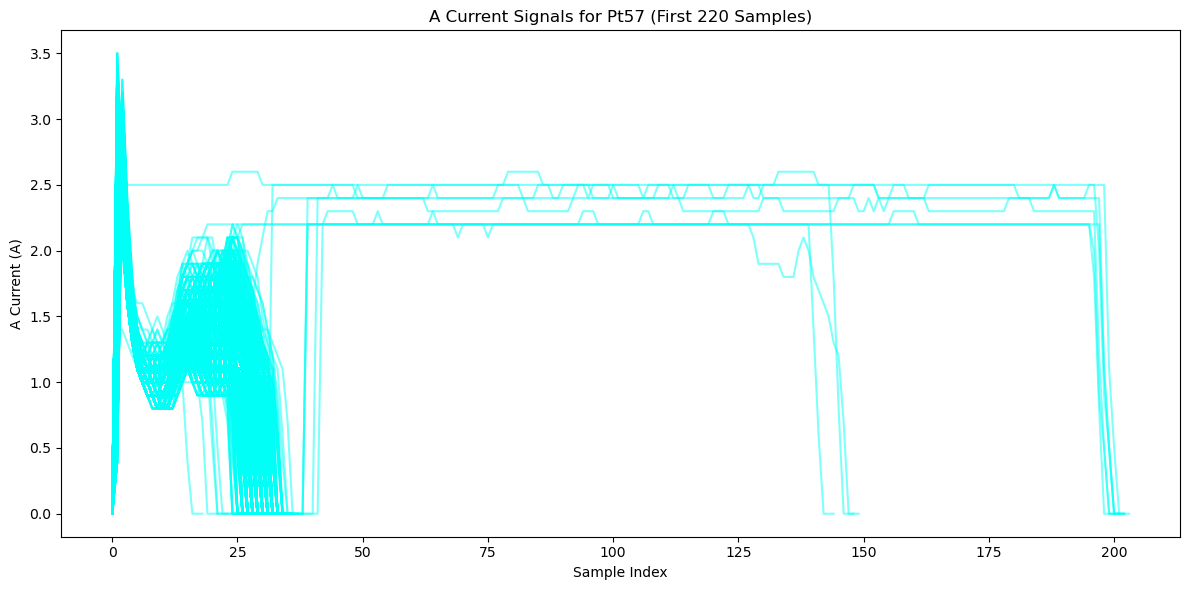

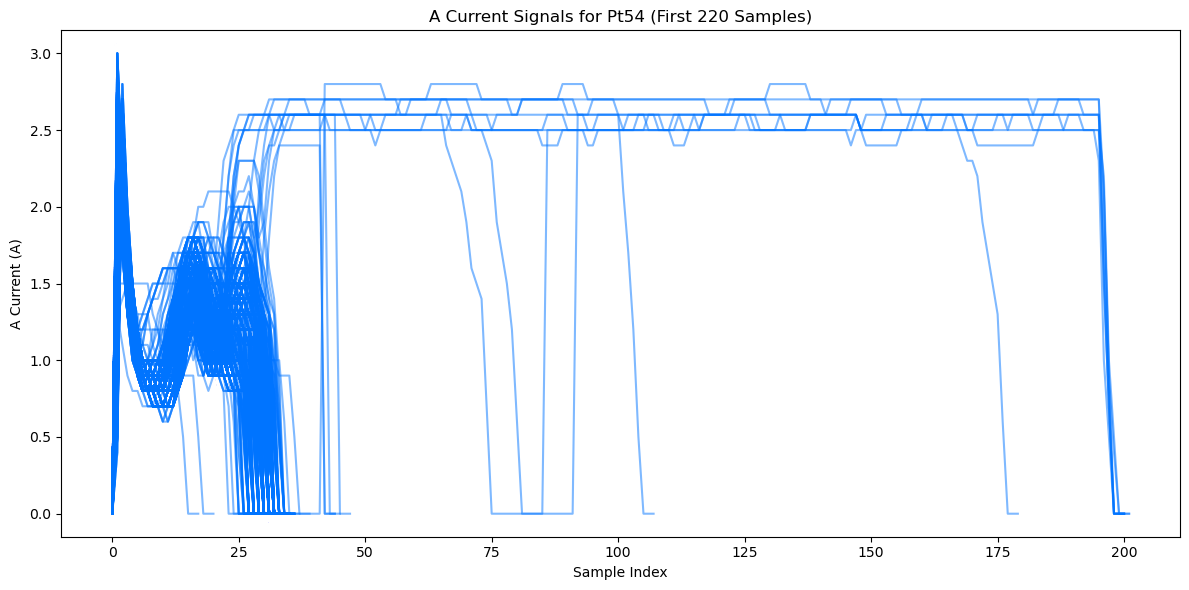

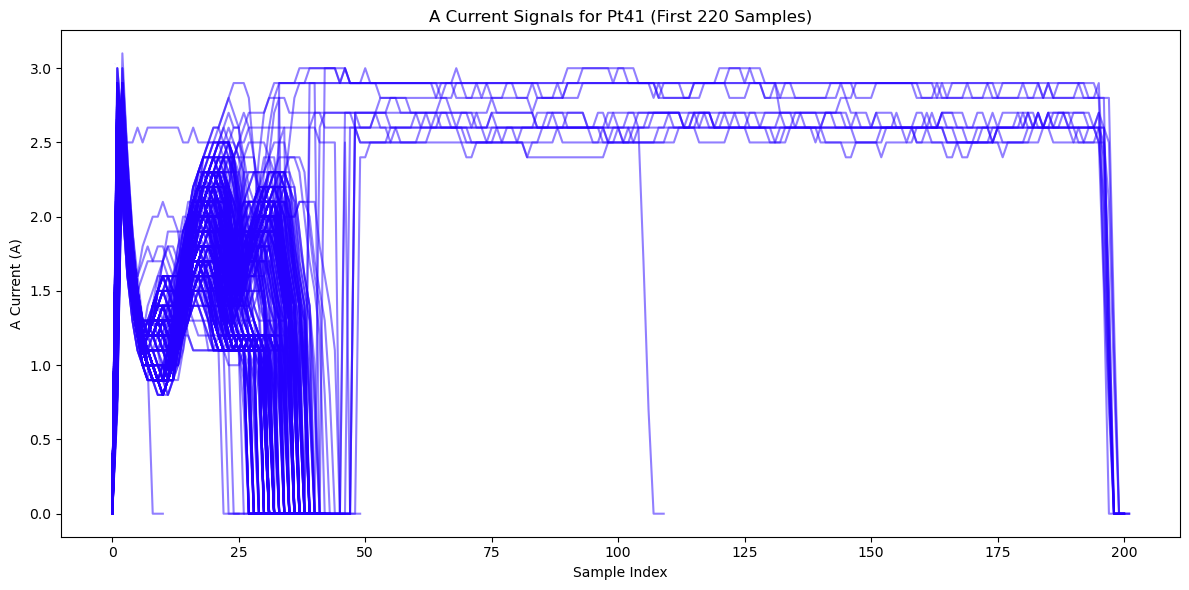

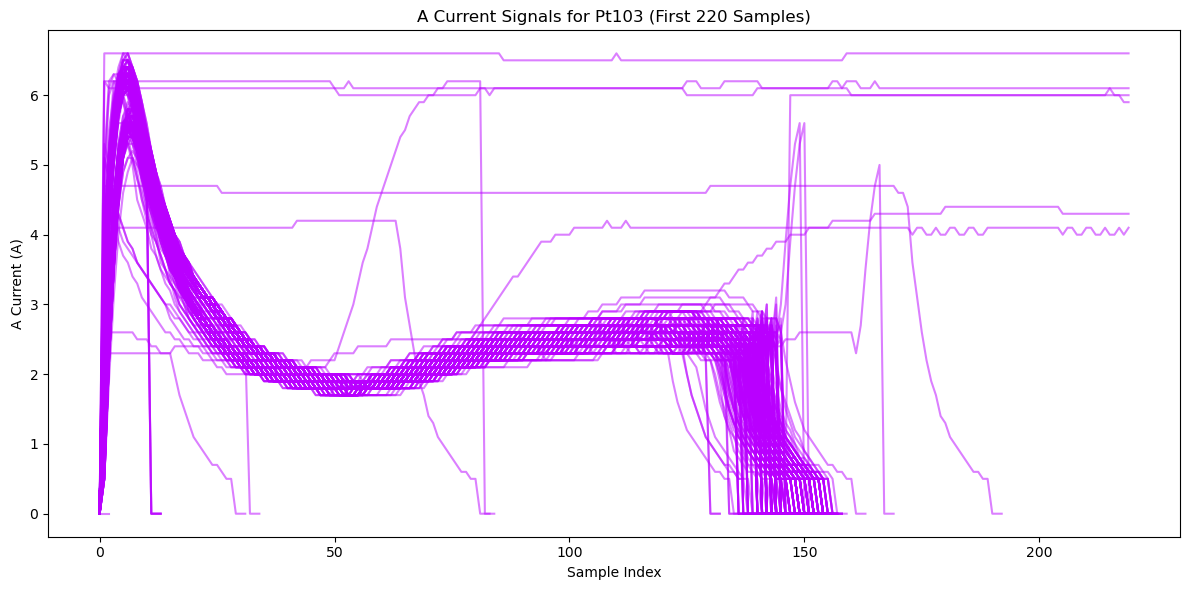

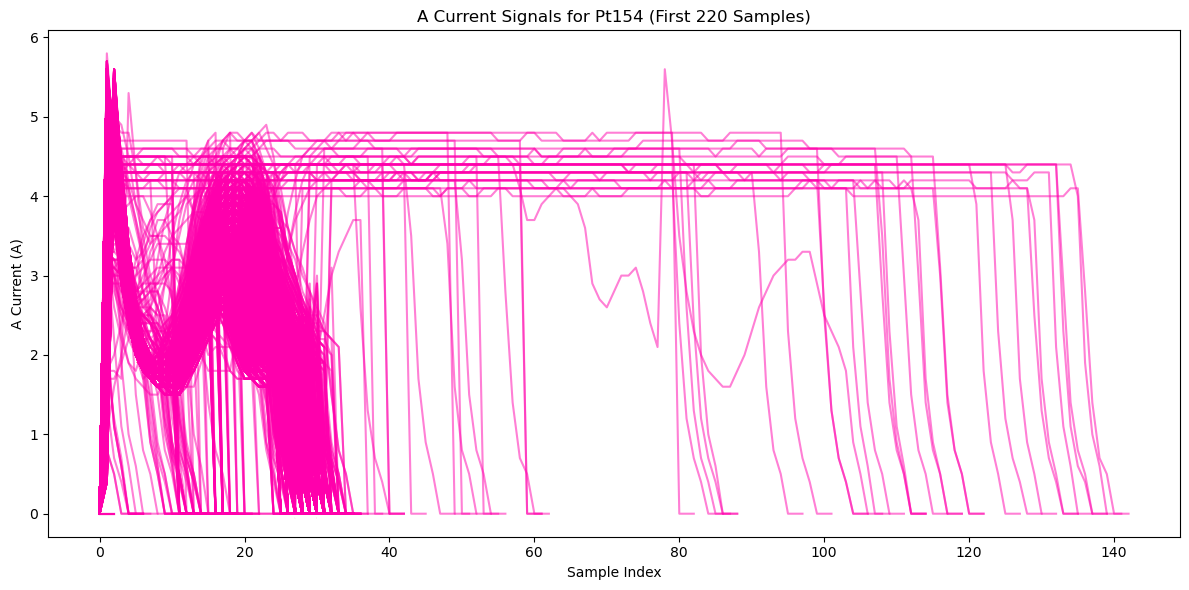

In [12]:
# Plot A Current signals for each point machine in a separate graph
for machine in unique_machines:
    machine_df = df[df['Point Machine Name'] == machine]
    plt.figure(figsize=(12, 6))
    for _, row in machine_df.iterrows():
        signal = row['A Current'][:220]
        plt.plot(signal, color=machine_color_map[machine], alpha=0.5)
    plt.title(f'A Current Signals for {machine} (First 220 Samples)')
    plt.xlabel('Sample Index')
    plt.ylabel('A Current (A)')
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np
import os

# 1. Prepare image data generator for loading images
img_dir = "signal_dataset_images_v2"
img_size = (128, 64)  # You can adjust based on your images
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    img_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
val_gen = datagen.flow_from_directory(
    img_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 2. Build a simple CNN for classification
model = models.Sequential([
    layers.Input(shape=(*img_size, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Train the model
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# 4. Feature extraction for clustering
feature_extractor = models.Model(inputs=model.input, outputs=model.layers[-2].output)
features = []
labels = []

for i in range(len(val_gen)):
    x_batch, y_batch = val_gen[i]
    feats = feature_extractor.predict(x_batch)
    features.append(feats)
    labels.append(np.argmax(y_batch, axis=1))
    if (i+1)*batch_size >= val_gen.samples:
        break

features = np.concatenate(features)
labels = np.concatenate(labels)

# 5. Dimensionality reduction and clustering
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

kmeans = KMeans(n_clusters=train_gen.num_classes, random_state=42)
clusters = kmeans.fit_predict(features)

# 6. Visualize clusters
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for i in range(train_gen.num_classes):
    plt.scatter(features_2d[clusters==i,0], features_2d[clusters==i,1], label=f'Cluster {i}', alpha=0.5)
plt.legend()
plt.title('KMeans Clusters of Signal Images')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

# 7. Classification report
y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes
print(classification_report(y_true, y_pred, target_names=list(val_gen.class_indices.keys())))

Found 720 images belonging to 9 classes.
Found 180 images belonging to 9 classes.
Epoch 1/10


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.1471 - loss: 3.4423 - val_accuracy: 0.1889 - val_loss: 2.1685
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2511 - loss: 2.1003 - val_accuracy: 0.3722 - val_loss: 1.6455
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5764 - loss: 1.3527 - val_accuracy: 0.6833 - val_loss: 1.0058
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7665 - loss: 0.7824 - val_accuracy: 0.7556 - val_loss: 0.8492
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8457 - loss: 0.5054 - val_accuracy: 0.7889 - val_loss: 0.7343
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8948 - loss: 0.3397 - val_accuracy: 0.8111 - val_loss: 0.7346
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9310 - loss: 0.2487 - val_accuracy: 0.8333 - val_loss: 0.6714
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9502 - loss: 0.1674 - val_accuracy: 0.8389 - val_loss: 0.

AttributeError: The layer sequential has never been called and thus has no defined input.